# Testing norm of gemma across layers

In [6]:
import torch as t
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_lens import HookedSAETransformer, SAE
import matplotlib.pyplot as plt
import numpy as np
t.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
# Load model and SAE
def load_model_and_sae(layer, device):
    model_name = "google/gemma-2-2b-it"
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        # quantization_config=quantization_config,
        device_map="cuda",
        torch_dtype=t.float32,
        # low_cpu_mem_usage=True,
    )
    model.eval()
    # model = HookedSAETransformer.from_pretrained(model_name, device=device)
    sae, _, _ = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=str(device),
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    sae.use_error_term = False
    return model, sae, tokenizer

# Setup

layer = 5
device = t.device("cuda" if t.cuda.is_available() else "cpu")
model, sae, tokenizer = load_model_and_sae(layer, device)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
# Load dataset and process multiple examples
import numpy as np
from tqdm import tqdm

def load_dataset_local(file_path, max_examples=1000, max_tokens=10):
    """Load dataset and truncate examples to max_tokens"""
    with open(file_path, 'r') as f:
        lines = f.readlines()[:max_examples]
    
    examples = []
    for line in lines:
        line = line.strip()
        # Tokenize and truncate to max_tokens
        tokens = tokenizer(line, return_tensors="pt", add_special_tokens=True, truncation=True)
        if tokens.input_ids.shape[1] > max_tokens:
            tokens.input_ids = tokens.input_ids[:, :max_tokens]
            tokens.attention_mask = tokens.attention_mask[:, :max_tokens]
        
        # Convert to dict and keep on CPU for storage
        token_dict = {k: v.cpu() for k, v in tokens.items()}
        examples.append(token_dict)
    
    return examples

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processing addition dataset...


addition: 100%|██████████| 500/500 [00:20<00:00, 24.40it/s]


Processing subtraction dataset...


subtraction: 100%|██████████| 500/500 [00:19<00:00, 25.24it/s]


Processing random_addition dataset...


random_addition: 100%|██████████| 500/500 [00:19<00:00, 25.13it/s]


Processing random_subtraction dataset...


random_subtraction: 100%|██████████| 500/500 [00:19<00:00, 25.13it/s]


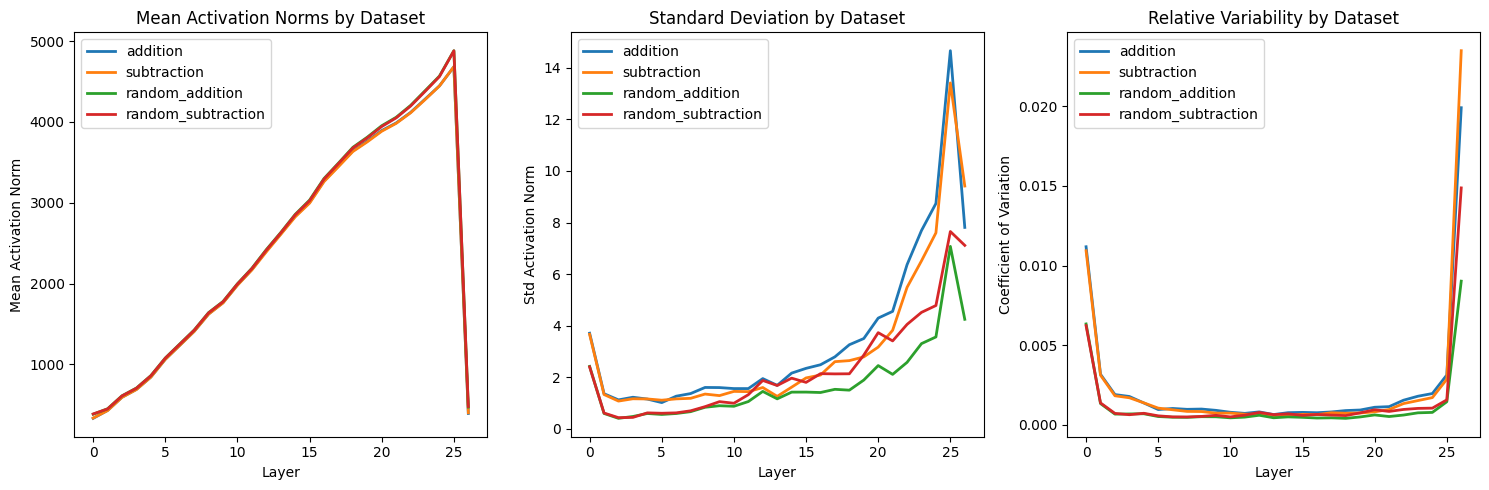

In [4]:
# Compare activation norms across different datasets
def compare_datasets():
    datasets = {
        'addition': '/home/ammar/gemma_scope_math/data/addition.txt',
        'subtraction': '/home/ammar/gemma_scope_math/data/subtraction.txt',
        'random_addition': '/home/ammar/gemma_scope_math/data/random_addition.txt',
        'random_subtraction': '/home/ammar/gemma_scope_math/data/random_subtraction.txt'
    }
    
    dataset_norms = {}
    dataset_activations = {}  # Add this to store activations
    
    for name, path in datasets.items():
        print(f"Processing {name} dataset...")
        examples = load_dataset_local(path, max_examples=500, max_tokens=10)  # Smaller sample for comparison
        
        norms = []
        activations = []  # Add this list to store activations
        
        for tokens in tqdm(examples, desc=name):
            # Move tokens to device properly
            if isinstance(tokens, dict):
                tokens = {k: v.to(device) for k, v in tokens.items()}
                input_ids = tokens['input_ids']
            else:
                tokens = tokens.to(device)
                input_ids = tokens.input_ids
            
            with t.no_grad():
                output = model(input_ids, output_hidden_states=True)
            
            # Store actual activations (move to CPU to save memory, like text_activations)
            hidden_states = [h.cpu() for h in output.hidden_states]
            activations.append(hidden_states)
            
            # Calculate norms as before
            layer_norms = [h.norm().item() for h in output.hidden_states]
            norms.append(layer_norms)
        
        dataset_norms[name] = np.array(norms)
        dataset_activations[name] = activations  # Store the activations
    
    # Plot comparison
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Mean norms comparison
    plt.subplot(1, 3, 1)
    for name, norms in dataset_norms.items():
        mean_norms = np.mean(norms, axis=0)
        plt.plot(mean_norms, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Mean Activation Norm")
    plt.title("Mean Activation Norms by Dataset")
    plt.legend()
    
    # Plot 2: Standard deviation comparison
    plt.subplot(1, 3, 2)
    for name, norms in dataset_norms.items():
        std_norms = np.std(norms, axis=0)
        plt.plot(std_norms, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Std Activation Norm")
    plt.title("Standard Deviation by Dataset")
    plt.legend()
    
    # Plot 3: Coefficient of variation comparison
    plt.subplot(1, 3, 3)
    for name, norms in dataset_norms.items():
        mean_norms = np.mean(norms, axis=0)
        std_norms = np.std(norms, axis=0)
        cv = std_norms / mean_norms
        plt.plot(cv, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Coefficient of Variation")
    plt.title("Relative Variability by Dataset")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return dataset_norms, dataset_activations  # Return both norms and activations

# Run the comparison
dataset_norms, dataset_activations = compare_datasets()

In [5]:
# Load and process text dataset for norm analysis
from datasets import load_dataset

def load_text_dataset(dataset_name="wikitext", split="train", max_examples=500, max_tokens=10):
    """Load a text dataset and truncate examples to max_tokens"""
    print(f"Loading {dataset_name} dataset...")
    
    # Load dataset from HuggingFace
    if dataset_name == "wikitext":
        dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "openwebtext":
        dataset = load_dataset("openwebtext", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "c4":
        dataset = load_dataset("c4", "en", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "bookcorpus":
        dataset = load_dataset("bookcorpus", split=split, streaming=True)
        text_field = "text"
    else:
        # Default to a simple text dataset
        dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=split, streaming=True)
        text_field = "text"
    
    examples = []
    count = 0
    
    for item in dataset:
        if count >= max_examples:
            break
            
        text = item[text_field].strip()
        if len(text) < 10:  # Skip very short texts
            continue
            
        # Tokenize and truncate to max_tokens
        tokens = tokenizer(text, return_tensors="pt", add_special_tokens=True, truncation=True)
        if tokens.input_ids.shape[1] > max_tokens:
            tokens.input_ids = tokens.input_ids[:, :max_tokens]
            tokens.attention_mask = tokens.attention_mask[:, :max_tokens]
        elif tokens.input_ids.shape[1] < 3:  # Skip very short tokenized sequences
            continue
        
        # Ensure tokens are on CPU for storage (will move to device during processing)
        tokens = {k: v.cpu() for k, v in tokens.items()}
        examples.append(tokens)
        count += 1
        
        if count % 100 == 0:
            print(f"Loaded {count} text examples...")
    
    print(f"Finished loading {len(examples)} text examples")
    return examples

# Load text dataset (using WikiText-2)
print("Loading text dataset for comparison...")
text_examples = load_text_dataset("wikitext", max_examples=500, max_tokens=10)

# Process text examples and collect both activations and norms
text_activations = []  # Store actual hidden states
text_activation_norms = []

print("Processing text examples...")
for i, tokens in enumerate(tqdm(text_examples, desc="Text processing")):
    # Ensure tokens are properly moved to device
    if isinstance(tokens, dict):
        tokens = {k: v.to(device) for k, v in tokens.items()}
        input_ids = tokens['input_ids']
    else:
        tokens = tokens.to(device)
        input_ids = tokens.input_ids
    
    with t.no_grad():
        output = model(input_ids, output_hidden_states=True)
    
    # Store actual activations (move to CPU to save memory)
    hidden_states = [h.cpu() for h in output.hidden_states]
    text_activations.append(hidden_states)
        
    # Calculate norm for each layer
    layer_norms = [h.norm().item() for h in output.hidden_states]
    text_activation_norms.append(layer_norms)

# Convert to numpy array
text_activation_norms = np.array(text_activation_norms)
print(f"Text dataset shape: {text_activation_norms.shape}")
print(f"Number of cached text activation sets: {len(text_activations)}")
print(f"Each text activation set contains {len(text_activations[0])} layers")
print(f"Shape of first layer text activation: {text_activations[0][0].shape}")

Loading text dataset for comparison...
Loading wikitext dataset...
Loaded 100 text examples...
Loaded 200 text examples...
Loaded 300 text examples...
Loaded 400 text examples...
Loaded 500 text examples...
Finished loading 500 text examples
Processing text examples...


Text processing: 100%|██████████| 500/500 [00:58<00:00,  8.51it/s]


Text dataset shape: (500, 27)
Number of cached text activation sets: 500
Each text activation set contains 27 layers
Shape of first layer text activation: torch.Size([1, 7, 2304])


=== MATH vs TEXT DATASET COMPARISON ===



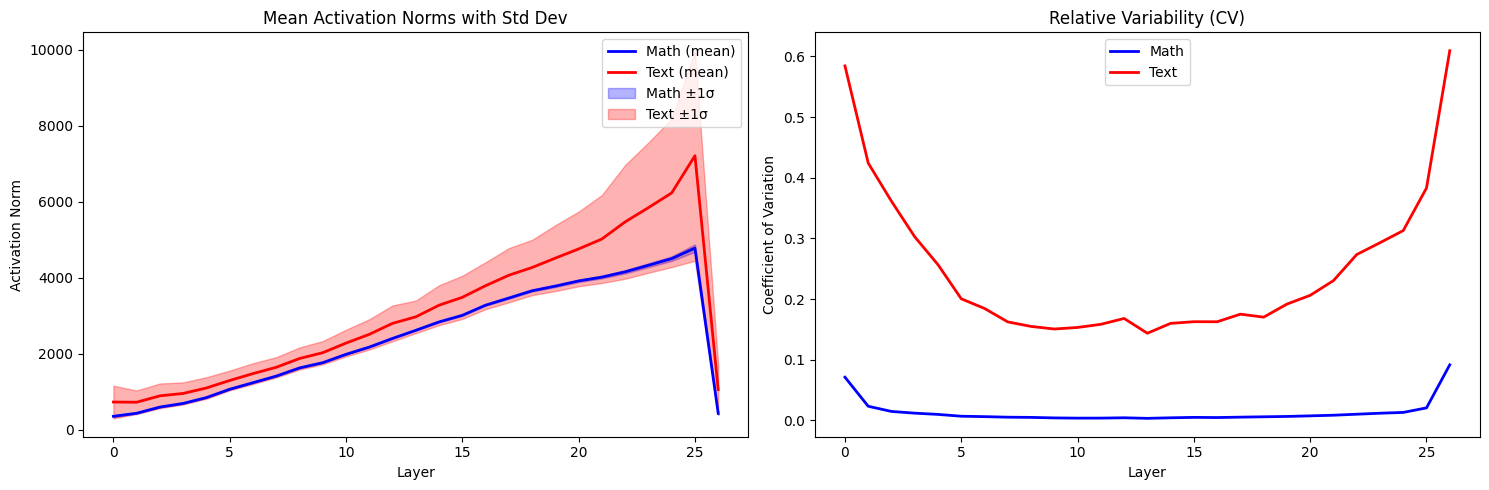

Dataset sizes:
  Math dataset: 2000 examples
  Text dataset: 500 examples

Overall statistics:
  Math - Mean: 2424.0750, Std: 1408.4211
  Text - Mean: 3049.4829, Std: 2067.4569

Mean coefficient of variation across layers:
  Math: 0.0138
  Text: 0.2495

Layer-wise t-test results (first 5 layers):
  Layer 0: t=-38.789, p=0.000000 ***
  Layer 1: t=-41.816, p=0.000000 ***
  Layer 2: t=-40.722, p=0.000000 ***
  Layer 3: t=-40.310, p=0.000000 ***
  Layer 4: t=-39.792, p=0.000000 ***


In [6]:
# Compare math vs text dataset activation norms
def compare_math_vs_text():
    """Compare activation norms between math and text datasets"""
    
    print("=== MATH vs TEXT DATASET COMPARISON ===\n")
    
    # Combine all math datasets
    all_math_norms = np.concatenate([dataset_norms['addition'], 
                                     dataset_norms['subtraction'], 
                                     dataset_norms['random_addition'], 
                                     dataset_norms['random_subtraction']], axis=0)
    
    # Calculate statistics for both datasets
    math_mean = np.mean(all_math_norms, axis=0)
    math_std = np.std(all_math_norms, axis=0)
    math_cv = math_std / math_mean
    
    text_mean = np.mean(text_activation_norms, axis=0)
    text_std = np.std(text_activation_norms, axis=0)
    text_cv = text_std / text_mean
    
    # Create comparison plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Mean comparison
    axes[0].plot(math_mean, 'b-', linewidth=2, label='Math (mean)')
    axes[0].plot(text_mean, 'r-', linewidth=2, label='Text (mean)')
    axes[0].fill_between(range(len(math_mean)), math_mean - math_std, math_mean + math_std, 
                           alpha=0.3, color='blue', label='Math ±1σ')
    axes[0].fill_between(range(len(text_mean)), text_mean - text_std, text_mean + text_std, 
                           alpha=0.3, color='red', label='Text ±1σ')
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Activation Norm")
    axes[0].set_title("Mean Activation Norms with Std Dev")
    axes[0].legend()
    
    # Plot 2: Coefficient of Variation comparison
    axes[1].plot(math_cv, 'b-', linewidth=2, label='Math')
    axes[1].plot(text_cv, 'r-', linewidth=2, label='Text')
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Coefficient of Variation")
    axes[1].set_title("Relative Variability (CV)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical comparison
    print(f"Dataset sizes:")
    print(f"  Math dataset: {all_math_norms.shape[0]} examples")
    print(f"  Text dataset: {text_activation_norms.shape[0]} examples")
    
    print(f"\nOverall statistics:")
    print(f"  Math - Mean: {np.mean(all_math_norms):.4f}, Std: {np.std(all_math_norms):.4f}")
    print(f"  Text - Mean: {np.mean(text_activation_norms):.4f}, Std: {np.std(text_activation_norms):.4f}")
    
    print(f"\nMean coefficient of variation across layers:")
    print(f"  Math: {np.mean(math_cv):.4f}")
    print(f"  Text: {np.mean(text_cv):.4f}")
    
    # Statistical test for difference in means
    from scipy.stats import ttest_ind
    
    print(f"\nLayer-wise t-test results (first 5 layers):")
    for i in range(min(5, len(math_mean))):
        t_stat, p_val = ttest_ind(all_math_norms[:, i], text_activation_norms[:, i])
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  Layer {i}: t={t_stat:.3f}, p={p_val:.6f} {significance}")
    
    return {
        'math_stats': {'mean': math_mean, 'std': math_std, 'cv': math_cv},
        'text_stats': {'mean': text_mean, 'std': text_std, 'cv': text_cv}
    }

# Run the comparison
comparison_results = compare_math_vs_text()

In [7]:
import os
import json
import numpy as np
import torch as t

# Create directory
os.makedirs('activation_mag_Test', exist_ok=True)

# Convert numpy arrays to lists for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.float32):
        return float(obj)
    else:
        return obj

# Save norms as JSON
with open('activation_mag_Test/dataset_norms.json', 'w') as f:
    json.dump(convert_to_serializable(dataset_norms), f)

with open('activation_mag_Test/text_activation_norms.json', 'w') as f:
    json.dump(convert_to_serializable(text_activation_norms), f)


# Save actual activations using torch.save
t.save(dataset_activations, 'activation_mag_Test/dataset_activations.pt')
t.save(text_activations, 'activation_mag_Test/text_activations.pt')


print("Saved activation norms to activation_mag_Test/ (JSON)")
print("Saved actual activations to activation_mag_Test/ (PyTorch)")

Saved activation norms to activation_mag_Test/ (JSON)
Saved actual activations to activation_mag_Test/ (PyTorch)


# SAE Activations norms

In [1]:
import json
import numpy as np
import torch as t
import gc
from typing import Dict, List
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_lens import HookedSAETransformer, SAE
t.set_grad_enabled(False)

# Load norms
with open('activation_mag_Test/dataset_norms.json', 'r') as f:
    dataset_norms = {k: np.array(v) for k, v in json.load(f).items()}

with open('activation_mag_Test/text_activation_norms.json', 'r') as f:
    text_activation_norms = np.array(json.load(f))


# Load actual activations
dataset_activations = t.load('activation_mag_Test/dataset_activations.pt')
text_activations = t.load('activation_mag_Test/text_activations.pt')


print("Loaded activation norms and activations from activation_mag_Test/")
print(f"Dataset norms keys: {list(dataset_norms.keys())}")
print(f"Text norms shape: {text_activation_norms.shape}")

print(f"Dataset activations keys: {list(dataset_activations.keys())}")
print(f"Text activations length: {len(text_activations)}")


Loaded activation norms and activations from activation_mag_Test/
Dataset norms keys: ['addition', 'subtraction', 'random_addition', 'random_subtraction']
Text norms shape: (500, 27)
Dataset activations keys: ['addition', 'subtraction', 'random_addition', 'random_subtraction']
Text activations length: 500


In [2]:
# Load SAEs for all layers and process cached activations through them

device = t.device("cuda" if t.cuda.is_available() else "cpu")

def load_sae_for_layer(layer: int, device):
    """Load SAE for a specific layer"""
    sae_id = f"layer_{layer}/width_16k/canonical"
    sae, _, _ = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=sae_id,
        device=str(device),
    )
    sae.use_error_term = False
    sae.eval()
    return sae

def process_activations_all_layers(cached_activations: List, device, layers_to_process=None):
    """
    Process cached activations through SAEs for specified layers
    
    Args:
        cached_activations: List of activation sets, each containing hidden states for all layers
        device: Device to use for computation
        layers_to_process: List of layer indices to process. If None, processes all layers up to 26
    
    Returns:
        sae_activations_by_layer: Dict mapping layer numbers to lists of SAE activations
        sae_norms_by_layer: Dict mapping layer numbers to lists of norms
    """
    sae_activations_by_layer = {}
    sae_norms_by_layer = {}
    loaded_saes = {}  # Cache SAEs to avoid reloading
    
    # Determine which layers to process
    if layers_to_process is None:
        # Default behavior: process up to 26 layers or actual number of layers
        if cached_activations:
            actual_layers = len(cached_activations[0])
            layers_to_process = list(range(min(26, actual_layers)))
        else:
            layers_to_process = list(range(26))
    
    print(f"Processing {len(cached_activations)} examples through {len(layers_to_process)} layers: {layers_to_process}...")
    
    for layer_idx in layers_to_process:
        print(f"  Processing layer {layer_idx}...")
        
        # Load SAE for this layer if not already loaded
        if layer_idx not in loaded_saes:
            try:
                loaded_saes[layer_idx] = load_sae_for_layer(layer_idx, device)
            except Exception as e:
                print(f"    Failed to load SAE for layer {layer_idx}: {e}")
                continue
        
        sae_activations = []
        sae_norms = []
        
        # Process each example through this layer's SAE
        for activation_set in cached_activations:
            layer_activation = activation_set[layer_idx].to(device)
            
            with t.no_grad():
                try:
                    # Encode through SAE
                    sae_encoded = loaded_saes[layer_idx].encode(layer_activation)
                    
                    # Calculate norm and move to CPU for storage
                    sae_norm = sae_encoded.norm().item()
                    sae_encoded_cpu = sae_encoded.cpu()
                    
                    sae_activations.append(sae_encoded_cpu)
                    sae_norms.append(sae_norm)
                    
                    # Clean up GPU memory
                    del layer_activation, sae_encoded
                    
                except Exception as e:
                    print(f"    Error processing example through layer {layer_idx}: {e}")
                    continue
        
        sae_activations_by_layer[layer_idx] = sae_activations
        sae_norms_by_layer[layer_idx] = sae_norms
        
        print(f"    Layer {layer_idx}: {len(sae_norms)} examples processed")
        print(f"    Mean SAE norm: {np.mean(sae_norms):.4f}, Std: {np.std(sae_norms):.4f}")
        
        # Clean up GPU memory periodically
        if len([l for l in layers_to_process if l <= layer_idx]) % 5 == 0:
            gc.collect()
            t.cuda.empty_cache()
    
    # Clean up loaded SAEs
    for sae in loaded_saes.values():
        del sae
    gc.collect()
    t.cuda.empty_cache()
    
    return sae_activations_by_layer, sae_norms_by_layer

# Process datasets through SAEs for all layers
print("=== PROCESSING CACHED ACTIVATIONS THROUGH SAEs (ALL LAYERS) ===\n")

# Dictionary to store SAE results for all layers
sae_results_all_layers = {}

# Process math datasets
print("Processing math datasets through SAEs...")
for dataset_name, activations in dataset_activations.items():
    if "random" in dataset_name:
        print(f"Skipping {dataset_name} dataset")
        continue
    print(f"\n--- Processing {dataset_name} dataset ({len(activations)} examples) ---")
    
    sae_acts_by_layer, sae_norms_by_layer = process_activations_all_layers(
        activations, device, layers_to_process=[0, 8, 16, 25,]
    )
    
    sae_results_all_layers[dataset_name] = {
        'activations_by_layer': sae_acts_by_layer,
        'norms_by_layer': sae_norms_by_layer
    }

# Process text dataset
print(f"\n--- Processing text dataset ({len(text_activations)} examples) ---")
text_sae_acts_by_layer, text_sae_norms_by_layer = process_activations_all_layers(
    text_activations, device, layers_to_process=[0, 8, 16, 25]
)

sae_results_all_layers['text'] = {
    'activations_by_layer': text_sae_acts_by_layer,
    'norms_by_layer': text_sae_norms_by_layer
}

print(f"\n=== SAE PROCESSING COMPLETE ===")
print(f"Processed {len(sae_results_all_layers)} datasets")
print(f"Each dataset has SAE activations for {len(text_sae_norms_by_layer)} layers")

# Convert SAE norms to format similar to original activation norms for plotting
dataset_sae_norms = {}
for dataset_name, results in sae_results_all_layers.items():
    norms_by_layer = results['norms_by_layer']
    
    # Convert from dict of lists to array format [examples, layers]
    if norms_by_layer:
        max_layer = max(norms_by_layer.keys())
        num_examples = len(norms_by_layer[0]) if 0 in norms_by_layer else 0
        
        if num_examples > 0:
            # Initialize array
            norms_array = np.full((num_examples, max_layer + 1), np.nan)
            
            # Fill in the data
            for layer_idx, norms_list in norms_by_layer.items():
                if len(norms_list) == num_examples:
                    norms_array[:, layer_idx] = norms_list
            
            dataset_sae_norms[dataset_name] = norms_array
            print(f"Dataset {dataset_name}: SAE norms shape {norms_array.shape}")

=== PROCESSING CACHED ACTIVATIONS THROUGH SAEs (ALL LAYERS) ===

Processing math datasets through SAEs...

--- Processing addition dataset (500 examples) ---
Processing 500 examples through 4 layers: [0, 8, 16, 25]...
  Processing layer 0...
    Layer 0: 500 examples processed
    Mean SAE norm: 491.6460, Std: 7.6974
  Processing layer 8...
    Layer 8: 500 examples processed
    Mean SAE norm: 2404.1631, Std: 0.3941
  Processing layer 16...
    Layer 16: 500 examples processed
    Mean SAE norm: 4649.8993, Std: 0.5142
  Processing layer 25...
    Layer 25: 500 examples processed
    Mean SAE norm: 4844.7554, Std: 5.0604

--- Processing subtraction dataset (500 examples) ---
Processing 500 examples through 4 layers: [0, 8, 16, 25]...
  Processing layer 0...
    Layer 0: 500 examples processed
    Mean SAE norm: 524.6369, Std: 7.2107
  Processing layer 8...
    Layer 8: 500 examples processed
    Mean SAE norm: 2403.5230, Std: 0.3658
  Processing layer 16...
    Layer 16: 500 examples p

: 

: 

: 

In [ ]:
# Create comparison plot for SAE activation norms
plt.figure(figsize=(15, 5))

# Plot 1: Mean SAE norms comparison
plt.subplot(1, 3, 1)
for name, norms in dataset_sae_norms.items():
    # Only plot layers that have data (not NaN)
    valid_layers = ~np.isnan(norms).all(axis=0)
    layer_indices = np.where(valid_layers)[0]
    mean_norms = np.nanmean(norms[:, valid_layers], axis=0)
    plt.plot(layer_indices, mean_norms, label=name, linewidth=2)
plt.xlabel("Layer")
plt.ylabel("Mean SAE Activation Norm")
plt.title("Mean SAE Activation Norms by Dataset")
plt.legend()

# Plot 2: Standard deviation comparison
plt.subplot(1, 3, 2)
for name, norms in dataset_sae_norms.items():
    valid_layers = ~np.isnan(norms).all(axis=0)
    layer_indices = np.where(valid_layers)[0]
    std_norms = np.nanstd(norms[:, valid_layers], axis=0)
    plt.plot(layer_indices, std_norms, label=name, linewidth=2)
plt.xlabel("Layer")
plt.ylabel("Std SAE Activation Norm")
plt.title("SAE Standard Deviation by Dataset")
plt.legend()

# Plot 3: Coefficient of variation comparison
plt.subplot(1, 3, 3)
for name, norms in dataset_sae_norms.items():
    valid_layers = ~np.isnan(norms).all(axis=0)
    layer_indices = np.where(valid_layers)[0]
    mean_norms = np.nanmean(norms[:, valid_layers], axis=0)
    std_norms = np.nanstd(norms[:, valid_layers], axis=0)
    cv = std_norms / mean_norms
    plt.plot(layer_indices, cv, label=name, linewidth=2)
plt.xlabel("Layer")
plt.ylabel("Coefficient of Variation")
plt.title("SAE Relative Variability by Dataset")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n=== SAE NORMS ANALYSIS COMPLETE ===")
print("SAE activation norms have been cached in 'dataset_sae_norms' variable")
print("Full results are in 'sae_results_all_layers' variable")

In [ ]:
with open('activation_mag_Test/dataset_sae_norms.json', 'w') as f:
    json.dump(convert_to_serializable(dataset_sae_norms), f)
t.save(sae_results_all_layers, 'activation_mag_Test/sae_results_all_layers.pt')
with open('activation_mag_Test/dataset_sae_norms.json', 'r') as f:
    dataset_sae_norms = {k: np.array(v) for k, v in json.load(f).items()}
sae_results_all_layers = t.load('activation_mag_Test/sae_results_all_layers.pt')
print(f"SAE results keys: {list(sae_results_all_layers.keys())}")
print(f"SAE norms keys: {list(dataset_sae_norms.keys())}")